# Deep Agents — পরিচিতি ও একটা মাল্টি-এজেন্ট রিসার্চ সিস্টেম

এই notebook-এ আমরা শিখব **Deep Agents** — [LangChain](https://docs.langchain.com/oss/python/deepagents/overview)-এর একটা প্যাটার্ন/লাইব্রেরি যেটা সাধারণ ReAct agent-কে **long-horizon, multi-step task** handle করার উপযোগী করে তোলে।

## 🔑 মূল প্রশ্ন

> সাধারণ tool-calling agent (`create_agent` + `bind_tools`) ছোট, ২-৩ ধাপের কাজে ভালো — কিন্তু **৩০+ ধাপের গবেষণা, কোডিং, বা multi-part কাজে** কেন ভেঙে পড়ে?

**Deep Agents**-এর উত্তর: agent-কে ৪টা নতুন ক্ষমতা দাও —

1. **Planning** — কাজ শুরুর আগে ধাপে ধাপে পরিকল্পনা (todo list) লেখা
2. **Filesystem** — সব intermediate output context window-এ না রেখে ফাইলে রাখা
3. **Sub-agents** — আলাদা "context window" সহ specialist agent-কে কাজ delegate করা
4. **Memory** — conversation শেষ হয়ে গেলেও গুরুত্বপূর্ণ তথ্য পরের conversation-এ ব্যবহার করা

## 📚 আজকে যা শিখব

| # | Topic |
|---|-------|
| 1 | সাধারণ ReAct agent কেন লম্বা, জটিল কাজে fail করে |
| 2 | Deep Agents-এর ৪টা স্তম্ভ — Planning, Filesystem, Sub-agents, Memory |
| 3 | `deepagents` লাইব্রেরি দিয়ে `create_deep_agent()` ব্যবহার করে বাস্তব agent বানানো |
| 4 | Tavily দিয়ে web-search tool বানানো |
| 5 | Research + Critique — দুটো sub-agent দিয়ে context isolation demo |
| 6 | `StoreBackend` + `InMemoryStore`/`InMemorySaver` দিয়ে thread-memory vs cross-thread memory |
| 7 | Agent-এর graph ও architecture visualize করা |
| 8 | সম্পূর্ণ end-to-end multi-step task চালিয়ে দেখা

> এই notebook-এ **Anthropic (Claude)** মডেল + **Tavily** web search API ব্যবহার করা হচ্ছে। দুটোরই key `.env`-এ থাকা দরকার (`ANTHROPIC_API_KEY`, `TAVILY_API_KEY`)।


---
## কেন সাধারণ ReAct Agent যথেষ্ট না?

আগের notebook-এ (`langgraph/1-basic-chatbot/1-basicChatbot.ipynb`) আমরা একটা ReAct agent বানিয়েছিলাম:

```
Human input → [model] → tool_calls? → [tools] → [model] → ... → Final Answer
```

এটা ছোট কাজে (একটা weather lookup, একটা calculation) পারফেক্ট। কিন্তু একটা **long-horizon task** ভাবো — যেমন:

> "Agentic RAG নিয়ে গবেষণা করে একটা রিপোর্ট লেখো, তারপর সেটা review করে finalize করো।"

এই কাজে সমস্যা হয়:

| সমস্যা | কেন হয় |
|---|---|
| **Context window overflow** | প্রতিটা search result, প্রতিটা draft — সবকিছু একই conversation-এ জমা হতে থাকে |
| **No plan, no memory of intent** | ১৫ ধাপ পরে agent ভুলে যায় original goal কী ছিল |
| **No isolation** | Research আর Critique — দুটো ভিন্ন persona/context একই conversation-এ মিশে যায়, output কম focused হয় |
| **Nothing persists** | Conversation শেষ → সব হারিয়ে যায়। পরের বার আবার শুরু থেকে |

**Deep Agents** এই ৪টা সমস্যার প্রতিটার জন্য একটা নির্দিষ্ট সমাধান দেয় — পরের সেকশনে।


---
## Deep Agents-এর ৪টা মূল স্তম্ভ (Pillars)

| # | স্তম্ভ | সমাধান করে | কীভাবে (deepagents lib-এ) |
|---|---|---|---|
| 1 | **Planning & Decomposition** | জটিল কাজ ভুলে যাওয়া / দিকভ্রষ্ট হওয়া | Built-in `write_todos` tool (`TodoListMiddleware`) — agent নিজেই ধাপে ধাপে to-do list বানায় ও আপডেট করে |
| 2 | **Filesystem / Context Offloading** | Context window overflow | Built-in `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep` tools (`FilesystemMiddleware`) — বড় ডেটা conversation-এ না রেখে ফাইলে রাখা যায় |
| 3 | **Sub-agents / Context Isolation** | ভিন্ন persona/subtask একে অপরের context-এ মিশে যাওয়া | `task()` tool (`SubAgentMiddleware`) — প্রতিটা sub-agent তার **নিজস্ব, খালি context window** নিয়ে কাজ শুরু করে, শেষে শুধু ফলাফল ফেরত দেয় |
| 4 | **Memory (short + long-term)** | Conversation শেষে সব হারিয়ে যাওয়া | `checkpointer` (thread-scoped, conversation history) + `store`-backed filesystem (cross-thread, persistent) |

### Architecture — এক নজরে

```
                         ┌─────────────────────────────┐
                         │      Main / Orchestrator      │
                         │            Agent              │
                         │  (write_todos দিয়ে plan করে)  │
                         └───────────────┬───────────────┘
                                         │  task(subagent_name, prompt)
                    ┌────────────────────┼────────────────────┐
                    ▼                    ▼                    ▼
          ┌─────────────────┐  ┌─────────────────┐  ┌─────────────────┐
          │  research-agent  │  │  critique-agent  │  │ general-purpose │
          │ (নিজস্ব context) │  │ (নিজস্ব context) │  │   (default)     │
          │  internet_search │  │   read_file      │  │   সব tools      │
          └────────┬─────────┘  └────────┬─────────┘  └─────────────────┘
                   │                     │
                   ▼                     ▼
          ┌───────────────────────────────────────────┐
          │        Shared Filesystem (Backend)         │
          │   report.md · critique.md · notes.md ...   │
          │  StateBackend (ephemeral) বা                │
          │  StoreBackend (persistent, cross-thread)   │
          └───────────────────────────────────────────┘
```

**মূল insight:** Sub-agent একটা আলাদা `task` tool-call — এটার নিজের system prompt, tool list, এবং message history আছে যা মূল agent-এর conversation-এ কখনো ঢোকে না। শুধু **চূড়ান্ত ফলাফল** (একটা string) মূল agent-কে ফেরত যায়। এটাই **context isolation**।


---
## কখন Deep Agents ব্যবহার করব?

| ব্যবহার করো যখন... | ব্যবহার কোরো না যখন... |
|---|---|
| কাজ **multi-step** এবং decomposition দরকার (গবেষণা রিপোর্ট, multi-file কোড রিফ্যাক্টর) | একটা single tool call-ই যথেষ্ট (আজকের আবহাওয়া কী?) |
| Intermediate output অনেক বড় (search result, লম্বা document, log file) | সব output ছোট, context window-তে সহজেই ধরে |
| ভিন্ন ভিন্ন persona/subtask দরকার (research vs writing vs review) | একটাই simple persona যথেষ্ট |
| কাজ শেষে কিছু **persist** করা দরকার (user preference, প্রজেক্ট state, পরের সেশনে কাজে লাগবে) | প্রতিটা conversation independent, কিছু মনে রাখার দরকার নেই |
| Latency কোনো বড় সমস্যা না (একাধিক LLM call + sub-agent call হবে) | Real-time / low-latency chat দরকার |

**নিয়ম মনে রাখার সহজ উপায়:** কাজটা যদি একজন মানুষকে TODO list লিখে, নোট নিয়ে, একজন colleague-কে সাহায্যের জন্য ডেকে করতে হতো — সেটা Deep Agent-এর কাজ। একটা প্রশ্নের এক-লাইন উত্তর হলে সাধারণ agent-ই যথেষ্ট।


---
## Step 1 — Environment Setup

`.env` থেকে দুটো key লাগবে:
- `ANTHROPIC_API_KEY` — Claude মডেল চালানোর জন্য (main agent + sub-agents)
- `TAVILY_API_KEY` — `research-agent`-এর জন্য real-time web search

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

print("ANTHROPIC_API_KEY:", bool(ANTHROPIC_API_KEY))
print("TAVILY_API_KEY   :", bool(TAVILY_API_KEY))

ANTHROPIC_API_KEY: True
TAVILY_API_KEY   : True


---
## Step 2 — Tavily Web Search Tool

Claude-এর training cutoff-এর পরের বা সাম্প্রতিক তথ্য জানতে হলে internet search লাগবে। `tavily-python`-এর `TavilyClient` দিয়ে একটা `@tool` বানানো হচ্ছে — এটাই পরে শুধু `research-agent` sub-agent-কে দেওয়া হবে (main agent বা `critique-agent`-কে না — যাতে delegation বাধ্যতামূলক হয়)।

In [2]:
from langchain_core.tools import tool
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


@tool
def internet_search(query: str, max_results: int = 4) -> str:
    """Search the web for current / real-time information using Tavily."""
    response = tavily_client.search(query=query, max_results=max_results)
    results = response.get("results", [])
    if not results:
        return "No results found."
    lines = []
    for r in results:
        lines.append(f"- {r['title']} ({r['url']})\n  {r['content'][:200]}")
    return "\n".join(lines)


# ── টেস্ট ──
print(internet_search.invoke({"query": "agentic RAG 2026 best practices", "max_results": 2}))

- Defensible RAG: 2026 Enterprise Implementation Best Practices (https://techplustrends.com/enterprise-rag-implementation-best-practices-2026)
  Enterprise RAG traceability flow diagram showing hybrid retrieval, RRF re-ranking, compliance validation, and structured audit logging in 2026. # Beyond the Tutorial: The 2026 Enterprise Standard for 
- Agentic RAG: Complete Guide to RAG 2026 (https://workativ.com/ai-agent/blog/agentic-rag)
  # Agentic RAG: Complete Guide to RAG in 2026. Agentic RAG complete guide: retrieval-augmented generation explained, implementation strategies, use cases, accuracy improvements & enterprise deployment 


---
## Step 3 — Planning Tool (`write_todos`)

`create_deep_agent()` দিয়ে বানানো যেকোনো agent স্বয়ংক্রিয়ভাবে একটা `write_todos` tool পায় (`TodoListMiddleware`)। আলাদা করে কিছু লিখতে হয় না — agent নিজেই জটিল instruction পেলে বুঝে নেয় যে আগে একটা plan লিখা দরকার, এবং কাজ এগোনোর সাথে সাথে সেই todo-list-এর status (`pending` → `in_progress` → `completed`) আপডেট করে।

```
User: "X নিয়ে গবেষণা করে রিপোর্ট লেখো এবং review করাও"
        ↓
write_todos([
  {"content": "X নিয়ে research করা",        "status": "pending"},
  {"content": "report.md লেখা",              "status": "pending"},
  {"content": "critique-agent দিয়ে review",  "status": "pending"},
  {"content": "feedback অনুযায়ী চূড়ান্ত করা", "status": "pending"},
])
```

এটা মানুষের হাতে লেখা TODO list-এর মতোই কাজ করে — agent নিজের কাজের progress track করতে পারে, এবং ভুলে যায় না original goal কী ছিল। পরের ধাপে যখন পুরো agent চালাবো, স্ট্রিমিং output-এ এই tool call-টা দেখা যাবে।

---
## Step 4 — Filesystem Tools ও Backend বেছে নেওয়া

`FilesystemMiddleware` সব agent/sub-agent-কে ৬টা ফাইল-টুল দেয়: `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`। এই tool গুলো **কোথায়** ফাইল রাখবে সেটা নির্ভর করে `backend`-এর উপর:

| Backend | ফাইল থাকে কোথায় | Persistence |
|---|---|---|
| `StateBackend` (default) | LangGraph state-এর ভেতরে | শুধু চলমান thread-এ, conversation শেষ হলে হারিয়ে যায় (checkpointer না থাকলে) |
| `FilesystemBackend` | আসল disk (host filesystem) | ডিস্কে যতক্ষণ ফাইল থাকে |
| `StoreBackend` | LangGraph-এর `BaseStore` | **সব thread/conversation জুড়ে persistent** — এটাই cross-thread memory-এর ভিত্তি |

আমরা `StoreBackend` + `InMemoryStore` ব্যবহার করব — এই process চলাকালীন সব thread (আলাদা `thread_id`) একই ফাইলগুলো access করতে পারবে। Production-এ `InMemoryStore`-এর জায়গায় Postgres/Redis-backed store বসালেই real persistence (process restart-এর পরেও টিকে থাকা) পাওয়া যায় — কোড অপরিবর্তিত থাকে।

সাথে `InMemorySaver` (checkpointer) দিয়ে **conversation history** (thread-scoped, short-term memory) রাখা হবে — এটা প্রতিটা `thread_id`-এর জন্য আলাদা, নতুন thread মানেই নতুন কথোপকথন।

In [3]:
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from deepagents.backends import StoreBackend

store = InMemoryStore()          # cross-thread persistent file storage
checkpointer = InMemorySaver()    # thread-scoped conversation memory

backend = StoreBackend(
    store=store,
    namespace=lambda rt: ("deepagents-demo", "filesystem"),  # সব thread এই namespace share করে
)

print("Store       :", type(store).__name__)
print("Checkpointer:", type(checkpointer).__name__)
print("Backend     :", type(backend).__name__)

G:\all projects\AI agents code\agentic-course-krish-naik\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Store       : InMemoryStore
Checkpointer: InMemorySaver
Backend     : StoreBackend


---
## Step 5 — Sub-agents তৈরি: Context Isolation

দুটো specialist sub-agent বানানো হচ্ছে — প্রতিটার **নিজস্ব system prompt এবং tool list** আছে:

| Sub-agent | কাজ | Tools | Context |
|---|---|---|---|
| `research-agent` | Web search করে ফলাফল ফাইলে লেখে | `internet_search` + built-in filesystem tools | শুধু নিজের research task-টুকু দেখে — মূল conversation দেখে না |
| `critique-agent` | একটা ফাইল পড়ে review লেখে | শুধু built-in filesystem tools (search নেই) | শুধু ফাইলের content + task instruction দেখে — research কীভাবে হয়েছে জানে না |

**লক্ষ্য করো:** `critique-agent`-কে ইচ্ছাকৃতভাবে `internet_search` দেওয়া হয়নি — ও শুধু যা ফাইলে লেখা আছে সেটার ভিত্তিতে review করবে, নতুন তথ্য বানিয়ে বলবে না। এটাই sub-agent দিয়ে **context/capability isolation**-এর সুবিধা — প্রতিটা sub-agent-কে ঠিক ততটুকুই ক্ষমতা দাও যতটুকু তার কাজের জন্য দরকার।

In [4]:
research_subagent = {
    "name": "research-agent",
    "description": (
        "Searches the web for information on a given topic and writes a concise "
        "summary to a file. Use this for any web-research subtask."
    ),
    "system_prompt": (
        "You are a research specialist. Use internet_search to gather up-to-date "
        "information on the given topic, then write a concise markdown summary "
        "(3-5 sentences) to the requested file using write_file. Cite source URLs briefly."
    ),
    "tools": [internet_search],
}

critique_subagent = {
    "name": "critique-agent",
    "description": (
        "Reads a written file and returns structured, actionable critique. "
        "Does not perform web research - review only."
    ),
    "system_prompt": (
        "You are an editor. Read the requested file with read_file, then write "
        "2-3 short, actionable critique bullet points to critique.md using write_file. "
        "Do not invent new facts - only comment on clarity, structure, and completeness."
    ),
    "tools": [],
}

print("Sub-agents defined:", research_subagent["name"], "&", critique_subagent["name"])

Sub-agents defined: research-agent & critique-agent


---
## Step 6 — মূল Deep Agent তৈরি করা

এখন সবকিছু `create_deep_agent()`-এ একসাথে জোড়া লাগানো হচ্ছে:

- `model` — orchestrator ও (override না করা পর্যন্ত) sub-agent-দের ডিফল্ট মডেল
- `system_prompt` — orchestrator-কে বলে দেওয়া হচ্ছে কখন plan করবে, কখন কোন sub-agent delegate করবে, এবং কাজ শেষে memory note লিখে রাখতে
- `subagents` — উপরের দুটো spec
- `backend` — `StoreBackend` (persistent, cross-thread ফাইল sharing)
- `checkpointer` / `store` — thread memory ও persistent store উভয়ই graph-এ bind হচ্ছে

`subagents`-এ `general-purpose` নামের কোনো entry না থাকায়, deepagents একটা default general-purpose sub-agentও যোগ করে দেবে — তাই আমাদের ৩টা sub-agent থাকবে: `research-agent`, `critique-agent`, `general-purpose`।

In [5]:
from langchain_anthropic import ChatAnthropic
from deepagents import create_deep_agent

model = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    anthropic_api_key=ANTHROPIC_API_KEY,
    max_tokens=4096,
)

ORCHESTRATOR_PROMPT = """তুমি একজন Deep Agent orchestrator।

নিয়ম:
1. জটিল, multi-step কাজ হলে প্রথমে write_todos দিয়ে পরিকল্পনা লেখো।
2. যেকোনো web-research/search দরকার হলে নিজে search করবে না - task() দিয়ে "research-agent" subagent-কে দাও।
3. Research শেষে report.md ফাইলে চূড়ান্ত answer লেখো, তারপর task() দিয়ে "critique-agent"-কে review করতে দাও।
4. Critique পড়ে দরকার হলে report.md আপডেট করো।
5. কাজ শেষে /notes.md ফাইলে ২ লাইনের সংক্ষিপ্ত সারাংশ write_file/edit_file দিয়ে রাখো, যাতে ভবিষ্যতে অন্য conversation থেকে filesystem access করলে context পাওয়া যায়।
6. সবসময় বাংলায় সংক্ষিপ্ত উত্তর দাও।"""

agent = create_deep_agent(
    model=model,
    system_prompt=ORCHESTRATOR_PROMPT,
    subagents=[research_subagent, critique_subagent],
    backend=backend,
    checkpointer=checkpointer,
    store=store,
)

print("Deep agent তৈরি হয়েছে!")
print("Type:", type(agent).__name__)

Deep agent তৈরি হয়েছে!
Type: CompiledStateGraph


---
## Step 7 — Agent Graph Visualization

Deep agent internally একটা LangGraph `CompiledStateGraph` — তাই আগের notebook-এর মতোই `draw_mermaid()` / `draw_mermaid_png()` দিয়ে দেখা যায়। Middleware (`TodoListMiddleware`, `PatchToolCallsMiddleware`, ইত্যাদি) graph-এ আলাদা hook-node হিসেবে যোগ হয়।

Nodes: ['__start__', 'model', 'tools', 'TodoListMiddleware.after_model', 'PatchToolCallsMiddleware.before_agent', '__end__']

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	TodoListMiddleware\2eafter_model(TodoListMiddleware.after_model)
	PatchToolCallsMiddleware\2ebefore_agent(PatchToolCallsMiddleware.before_agent)
	__end__([<p>__end__</p>]):::last
	PatchToolCallsMiddleware\2ebefore_agent --> model;
	TodoListMiddleware\2eafter_model -.-> __end__;
	TodoListMiddleware\2eafter_model -.-> model;
	TodoListMiddleware\2eafter_model -.-> tools;
	__start__ --> PatchToolCallsMiddleware\2ebefore_agent;
	model --> TodoListMiddleware\2eafter_model;
	tools -.-> model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



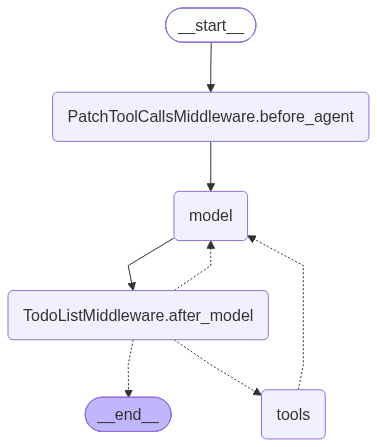

In [6]:
from IPython.display import Image, display

print("Nodes:", list(agent.get_graph().nodes.keys()))
print()
print(agent.get_graph().draw_mermaid())

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG render skipped: {e}")
    print("উপরের mermaid text/diagram দেখো।")

**এই graph-এ `model` ↔ `tools` লুপ-টাই মূল ReAct loop** — `task()` (sub-agent call), `write_todos`, `write_file` ইত্যাদি সবই `tools` node দিয়ে পাস হয়। `task()` কল হলে ভেতরে ভেতরে একটা সম্পূর্ণ আলাদা compiled sub-graph (sub-agent নিজের model↔tools loop) চলে — যেটা এই top-level graph-এ দেখা যাচ্ছে না, ঠিক যেমন আগের ASCII architecture diagram-এ দেখানো হয়েছিল। Sub-agent-এর ভেতরের সেই loop সম্পূর্ণ **isolated** — তার message history top-level `agent`-এর state-এ কখনো যোগ হয় না, শুধু final result string হিসেবে ফেরত আসে।

---
## Step 8 — সম্পূর্ণ Multi-Step Task চালানো (Thread A)

এখন একটা বাস্তব জটিল কাজ দেওয়া হচ্ছে যেটা **প্ল্যানিং + delegation + filesystem + web-search** — সবকিছু একসাথে ব্যবহার করবে:

> "Agentic RAG-এর সাম্প্রতিক (২০২৫-২০২৬) best practice নিয়ে গবেষণা করে একটা সংক্ষিপ্ত রিপোর্ট লেখো, critique-agent দিয়ে review করাও, তারপর ফাইনাল ভার্সন দাও।"

`stream_mode="updates"` দিয়ে প্রতিটা node/tool-call আলাদা করে দেখা যাবে — planning, sub-agent delegation, filesystem write — সবকিছু।

In [7]:
import uuid

TASK = (
    "'Agentic RAG'-এর সাম্প্রতিক (২০২৫-২০২৬) সেরা practice নিয়ে গবেষণা করে "
    "৩-৪ বাক্যের একটা সংক্ষিপ্ত report.md লেখো। তারপর critique-agent দিয়ে review করিয়ে "
    "প্রয়োজনে ফাইনাল ভার্সন আপডেট করো।"
)

thread_a = {"configurable": {"thread_id": str(uuid.uuid4())}}
print("Thread A ID:", thread_a["configurable"]["thread_id"][:8], "...\n")

for event in agent.stream(
    {"messages": [{"role": "user", "content": TASK}]},
    config=thread_a,
    stream_mode="updates",
):
    for node_name, node_output in event.items():
        if not isinstance(node_output, dict):
            continue
        for msg in node_output.get("messages", []):
            tool_calls = getattr(msg, "tool_calls", None)
            if tool_calls:
                for tc in tool_calls:
                    args_preview = str(tc.get("args", {}))[:90]
                    print(f"  [{node_name}] TOOL CALL -> {tc['name']}({args_preview})")
            elif getattr(msg, "name", None):
                content_preview = str(msg.content)[:120].replace("\n", " ")
                print(f"  [{node_name}] TOOL RESULT ({msg.name}): {content_preview}")
            else:
                content = getattr(msg, "content", "")
                content_preview = str(content)[:150].replace("\n", " ")
                if content_preview.strip():
                    print(f"  [{node_name}] MESSAGE: {content_preview}")

Thread A ID: 1b039ae9 ...



  [model] TOOL CALL -> task({'subagent_type': 'research-agent', 'description': 'গবেষণা করো "Agentic RAG" (Retrieval-Au)


  [tools] TOOL RESULT (task): নিখুঁত! আমি Agentic RAG সম্পর্কে গভীর গবেষণা সম্পন্ন করেছি এবং ফলাফল `report.md` ফাইলে লিখেছি।  ## গবেষণার ফলাফল  **Agen


  [model] TOOL CALL -> task({'subagent_type': 'critique-agent', 'description': 'কৃতিত্বপূর্ণভাবে review করো `/report.m)


  [tools] TOOL RESULT (task): ## Review সম্পূর্ণ! 📋  আমি `/report.md` ফাইলটি সতর্কতার সাথে পর্যালোচনা করে **`critique.md`** তে বিস্তারিত মূল্যায়ন প্র


  [model] TOOL CALL -> read_file({'file_path': '/report.md'})
  [tools] TOOL RESULT (read_file):      1	# Agentic RAG: Best Practices Summary (2025-2026)      2	      3	## Overview      4	      5	Agentic RAG (Retrieva


  [model] TOOL CALL -> edit_file({'file_path': '/report.md', 'old_string': '# Agentic RAG: Best Practices Summary (2025-202)
  [tools] TOOL RESULT (edit_file): Successfully replaced 1 instance(s) of the string in '/report.md'


  [model] TOOL CALL -> read_file({'file_path': '/report.md'})
  [tools] TOOL RESULT (read_file):      1	# Agentic RAG: Best Practices Summary (2025-2026)      2	      3	Agentic RAG treats retrieval as an agentic tool 


  [model] TOOL CALL -> write_file({'file_path': '/notes.md', 'content': '# Session Summary\n\n- **Task**: গবেষণা করে Agentic)
  [tools] TOOL RESULT (write_file): Updated file /notes.md


  [model] MESSAGE: ---  ✅ **কাজ সম্পন্ন**  **Agentic RAG Best Practices (২০২৫-२०२६):**  Agentic RAG treats retrieval as an agentic tool within reasoning loops, enabling 


---
## Step 9 — ফলাফল ফাইল দেখা

Orchestrator এবং sub-agent-রা যে ফাইল লিখেছে সেগুলো এখন সরাসরি `store`-এর namespace থেকে দেখা যায় — কোনো নতুন LLM call ছাড়াই, কারণ `StoreBackend`-এর সব ডেটা `store` object-এ (আমাদের কাছেই আছে)।

In [8]:
namespace = ("deepagents-demo", "filesystem")

print("Store-এ থাকা ফাইলসমূহ:")
for item in store.search(namespace):
    print(" -", item.key)

print()
report_item = store.get(namespace, "/report.md")
if report_item:
    print("=" * 50)
    print("report.md")
    print("=" * 50)
    print(report_item.value["content"])

critique_item = store.get(namespace, "/critique.md")
if critique_item:
    print()
    print("=" * 50)
    print("critique.md")
    print("=" * 50)
    print(critique_item.value["content"])

Store-এ থাকা ফাইলসমূহ:
 - /report.md
 - /critique.md
 - /notes.md

report.md
# Agentic RAG: Best Practices Summary (2025-2026)

Agentic RAG treats retrieval as an agentic tool within reasoning loops, enabling autonomous systems to dynamically refine queries, self-correct, and make contextual decisions about when and what to retrieve. Key best practices include implementing iteration budgets and reflection loops to control agent behavior, using query expansion and adaptive retrieval techniques (self-querying), and establishing multi-dimensional evaluation metrics for retrieval quality, relevance, and latency. Production frameworks like LangGraph combined with ReAct patterns allow agents to iteratively evaluate retrieved content and synthesize multi-step answers while maintaining cost-efficiency. Success requires comprehensive observability, explicit cost controls, and specialized agent architectures that balance accuracy with computational constraints.

## Sources

- [Agentic RAG in 202

---
## Step 10 — Persistent Memory: নতুন Thread (Thread B), একই Store

এখন **সম্পূর্ণ নতুন `thread_id`** দিয়ে agent-কে ডাকা হচ্ছে — অর্থাৎ এটা একটা ব্র্যান্ড-নিউ conversation, `checkpointer`-এ এই thread-এর কোনো history নেই। কিন্তু `store` (এবং তাই filesystem) আগের session-এর সাথে **শেয়ার্ড** — তাই agent আগের কাজের ফাইল পড়তে পারবে।

এটাই মূল পার্থক্য:
- **Thread memory (checkpointer)** → conversation-scoped, নতুন thread মানেই শূন্য থেকে শুরু
- **Long-term memory (store-backed filesystem)** → cross-thread, সব conversation জুড়ে persistent

In [9]:
thread_b = {"configurable": {"thread_id": str(uuid.uuid4())}}
print("Thread B ID:", thread_b["configurable"]["thread_id"][:8], "(সম্পূর্ণ নতুন conversation)\n")

result_b = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "আমরা কি আগে কথা বলেছি? তোমার conversation history-তে কিছু আছে কি? "
                    "তারপর ls করে filesystem-এ কী কী ফাইল আছে দেখাও, এবং notes.md পড়ে "
                    "বলো আগের session-এ কোন topic নিয়ে কাজ হয়েছিল।"
                ),
            }
        ]
    },
    config=thread_b,
)
print(result_b["messages"][-1].content)

Thread B ID: 874bfcab (সম্পূর্ণ নতুন conversation)



**Filesystem স্ট্যাটাস:**

তিনটি ফাইল আছে:
- `/notes.md` - আগের session-এর সংক্ষিপ্ত note
- `/report.md` - Agentic RAG (2025-2026) সম্পর্কে গবেষণা রিপোর্ট
- `/critique.md` - সেই রিপোর্টের critique

**আগের কাজ:** 
Agentic RAG (Retrieval-Augmented Generation) এর 2025-2026 সালের best practices নিয়ে গবেষণা করা হয়েছিল। মূল ফোকাস ছিল retrieval-কে agentic tool হিসেবে ব্যবহার, iteration budgets, reflection loops, query expansion, metrics, LangGraph/ReAct patterns এবং cost control নিয়ে।

বর্তমান session-এ কি নতুন কিছু করতে চাও?


---
## Thread Memory vs Long-Term Memory — পাশাপাশি তুলনা

| বিষয় | Checkpointer (`InMemorySaver`) | Store-backed Filesystem (`StoreBackend`) |
|---|---|---|
| Scope | একটা নির্দিষ্ট `thread_id` | সব `thread_id` জুড়ে shared |
| কী রাখে | পুরো message history (conversation) | ফাইল content (`write_file`/`edit_file` দিয়ে যা লেখা হয়েছে) |
| নতুন thread-এ কী হয় | শূন্য থেকে শুরু (কোনো আগের বার্তা নেই) | আগের ফাইল এখনও access করা যায় |
| Production equivalent | Postgres/SQLite checkpointer | Postgres/Redis-backed `BaseStore` |
| কাজে লাগে | Multi-turn conversation-এ context রাখতে | User preference, project notes, session-এর মাঝে persist করা তথ্যের জন্য |

**ব্যবহারিক প্যাটার্ন:** Orchestrator-এর system prompt-এ আমরা বলে দিয়েছিলাম "কাজ শেষে `/notes.md`-এ সারাংশ লিখে রাখো" — এটাই deep agent-এর long-term memory প্যাটার্ন: explicit tool call (`write_file`) দিয়ে যা persist করা দরকার তা ফাইলে লেখা, তারপর যেকোনো ভবিষ্যৎ conversation সেই ফাইল পড়তে পারে।

---
## ✅ Summary — কী শিখলাম

এই notebook-এ আমরা একটা সম্পূর্ণ **Deep Agent** system বানিয়েছি:

1. **সাধারণ ReAct agent-এর সীমাবদ্ধতা** — context overflow, no plan-tracking, no isolation, no persistence
2. **৪টা স্তম্ভ** — Planning (`write_todos`), Filesystem (`ls`/`read_file`/`write_file`/`edit_file`/`glob`/`grep`), Sub-agents (`task`), Memory (checkpointer + store)
3. **`internet_search`** — Tavily দিয়ে বানানো custom tool, শুধু `research-agent`-কে দেওয়া হয়েছে
4. **`research-agent` ও `critique-agent`** — আলাদা system prompt, আলাদা tool-set, আলাদা (isolated) context
5. **`StoreBackend` + `InMemoryStore`** — cross-thread persistent filesystem
6. **`InMemorySaver`** — thread-scoped conversation memory
7. **Graph visualization** — `draw_mermaid()`/`draw_mermaid_png()` দিয়ে agent-এর internal loop, এবং architecture ASCII diagram দিয়ে sub-agent delegation flow

### Key Classes / Functions

| Class / Function | Package | কাজ |
|---|---|---|
| `create_deep_agent` | `deepagents` | Planning + filesystem + subagent + memory middleware সহ agent বানায় |
| `SubAgent` (dict spec) | `deepagents` | নাম, description, system_prompt, tools দিয়ে sub-agent define করা |
| `StoreBackend` | `deepagents.backends` | Filesystem tool-কে `BaseStore`-এর সাথে যুক্ত করে (persistent) |
| `InMemoryStore` | `langgraph.store.memory` | Cross-thread key-value store (demo/dev) |
| `InMemorySaver` | `langgraph.checkpoint.memory` | Thread-scoped conversation checkpointing (demo/dev) |
| `task` (auto tool) | — | Main agent থেকে sub-agent-কে delegate করার tool |

### সাধারণ Agent vs Deep Agent

| | সাধারণ `create_agent` | `create_deep_agent` |
|---|---|---|
| Planning | নেই (manual) | `write_todos` built-in |
| Context management | সব একই conversation-এ | Filesystem-এ offload করা যায় |
| Delegation | নেই | `task()` দিয়ে isolated sub-agent |
| Cross-conversation memory | শুধু checkpointer (thread-scoped) | `store`-backed filesystem (cross-thread) |
| উপযোগী | ছোট, ২-৩ ধাপের কাজ | লম্বা, multi-step, multi-persona কাজ |

### 🔗 Reference

- [LangChain Deep Agents docs](https://docs.langchain.com/oss/python/deepagents/overview)
- [Tavily API](https://tavily.com)
